This template validates the measurement files a LOGR | Solar writes about the site: the statistical (`_statistical.dat`) files carrying the Avg, Min, Max and SD of every channel over each interval, or the one-second (`_onesecond.dat`) files carrying the samples themselves.

Every channel the header can be read for is checked, the results are summarized, and every signal is plotted for visual inspection. Unlike a ProtoNode capture or a `.diag` file there is no fixed spec to check against -- no two sites have the same channels -- so `measurement.spec_for` builds one out of the file's own Sensor History header.

Use `Process_LOGR_Meas_Files.ipynb` if you only want to read and plot the files, `Validate_LOGR_Diag_Files.ipynb` for the diagnostic files a logger writes about itself, or `Validate_ProtoNode_File.ipynb` for a Modbus Data Client capture.

In [1]:
import pandas as pd

from se_analysis import measurement, project, read_files, validation
from se_analysis.plot import plot_signals, plot_together

Modify this cell to point to the directory holding the `.dat` files. `project` finds your configured project directory, set in the `SE_PROJECTS_DIR` variable in the `.env` file.

`file_type` selects which measurement files to read: `"statistical"` or `"onesecond"`. The error nrgpy logs below is a bug in nrgpy; you can ignore it.

In [2]:
data_dir = project("SRM", "Panama-NE", "data", "MET1", "MET")
reader = read_files(data_dir, file_type="statistical")

2026-09-15 12:32:59,829 | INFO | [logr:559] | Concatenating 26 files...


Time elapsed: 0 s | 26  / 26  [=============================================] 100%	

2026-09-15 12:33:00,581 | ERROR | [logr:661] | could not sort ch_info
Traceback (most recent call last):
  File "c:\Users\bft\code\se-analysis\.venv\Lib\site-packages\nrgpy\read\logr.py", line 658, in concat_txt
    .drop(columns=["ch", "Channel"], axis=1, errors="ignore")
     ~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\bft\code\se-analysis\.venv\Lib\site-packages\pandas\core\frame.py", line 6302, in drop
    return super().drop(
           ~~~~~~~~~~~~^
        labels=labels,
        ^^^^^^^^^^^^^^
    ...<5 lines>...
        errors=errors,
        ^^^^^^^^^^^^^^
    )
    ^
  File "c:\Users\bft\code\se-analysis\.venv\Lib\site-packages\pandas\core\generic.py", line 4619, in drop
    raise ValueError("Cannot specify both 'axis' and 'index'/'columns'")
ValueError: Cannot specify both 'axis' and 'index'/'columns'
2026-09-15 12:33:00,644 | INFO | [logr:677] | Concatenation of 1379 rows complete


Display the site info to make sure you're using the correct data files. The `Latitude` and `Longitude` here are what the solar angle check is run against, so a site configured with the wrong position shows up as an angle finding later.

In [3]:
reader.Site_info

,0,1
0,Model Number:,9432
1,Serial Number:,3130
2,Created FW Version:,1.13.06
3,Site Properties,NaN
4,Site:,3130
...,...,...
300,Serial Number:,09105750
301,Scale Factor:,0.200000
302,Offset:,0.000000
303,Height:,0.00


`indexed` puts the frame on its timestamp, oldest first, and renames the `Ch<n>_<stat>_<units>` columns to the labels the header describes them with -- a finding against `Ch108_Avg_Hukseflux_SR30-POA_Irradiance_W/m^2` says which sensor to go and look at where one against `Ch108_Avg_W/m^2` does not. The stamps are written with a `Z`, so unlike the ProtoNode exports these files are already UTC.

In [4]:
df = measurement.indexed(reader.data, reader.Site_info)
df

,Ch1_Avg_IMT_Si-V-1.5TC-T_Irradiance-POA_W/m^2,Ch1_Min_IMT_Si-V-1.5TC-T_Irradiance-POA_W/m^2,Ch1_Max_IMT_Si-V-1.5TC-T_Irradiance-POA_W/m^2,Ch1_SD_IMT_Si-V-1.5TC-T_Irradiance-POA_W/m^2,Ch2_Avg_IMT_Si-V-1.5TC-T_Temperature-POA_deg_C,Ch2_Min_IMT_Si-V-1.5TC-T_Temperature-POA_deg_C,Ch2_Max_IMT_Si-V-1.5TC-T_Temperature-POA_deg_C,Ch2_SD_IMT_Si-V-1.5TC-T_Temperature-POA_deg_C,Ch3_Avg_IMT_Si-V-1.5TC-T_Irradiance-RPOA_W/m^2,Ch3_Min_IMT_Si-V-1.5TC-T_Irradiance-RPOA_W/m^2,...,Ch403_Avg_NRG_40_Anemometer_m/s,Ch403_Min_NRG_40_Anemometer_m/s,Ch403_Max_NRG_40_Anemometer_m/s,Ch403_SD_NRG_40_Anemometer_m/s,Ch403_Gust_NRG_40_Anemometer_m/s,Ch404_Avg_Texas_El._TR-525-W2S_mm,Ch404_Min_Texas_El._TR-525-W2S_mm,Ch404_Max_Texas_El._TR-525-W2S_mm,Ch404_SD_Texas_El._TR-525-W2S_mm,Ch404_Total_Texas_El._TR-525-W2S_mm
Timestamp,,,,,,,,,,,,,,,,,,,,,
2026-09-10 00:00:00+00:00,234.6484,222.2132,241.5707,6.1968,30.8192,30.8107,30.8318,0.0061,15.6610,15.3575,...,0.3500,0.350,0.350,0.0000,0.350,0.0,0.0,0.0,0.0,0.0
2026-09-10 00:01:00+00:00,224.0363,208.6072,237.2370,6.2443,30.8304,30.8139,30.8535,0.0136,15.1793,14.6628,...,0.3500,0.350,0.350,0.0000,0.350,0.0,0.0,0.0,0.0,0.0
2026-09-10 00:02:00+00:00,154.8071,124.9748,206.2645,23.5602,30.6908,30.4531,30.8493,0.1305,13.0475,12.2159,...,0.3500,0.350,0.350,0.0000,0.350,0.0,0.0,0.0,0.0,0.0
2026-09-10 00:03:00+00:00,197.7443,167.9756,211.6745,16.1987,30.3337,30.2901,30.4473,0.0455,13.9829,13.1764,...,0.3500,0.350,0.350,0.0000,0.350,0.0,0.0,0.0,0.0,0.0
2026-09-10 00:04:00+00:00,184.6304,145.2439,209.8440,21.0464,30.2415,30.1457,30.2929,0.0522,13.5346,12.5187,...,0.3500,0.350,0.350,0.0000,0.350,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-09-10 23:55:00+00:00,68.1079,66.8585,69.3339,0.7404,28.1861,28.1474,28.2239,0.0225,12.0091,11.7213,...,3.2442,1.880,4.175,0.5991,3.920,0.0,0.0,0.0,0.0,0.0
2026-09-10 23:56:00+00:00,65.5948,64.3677,66.7767,0.7196,28.1059,28.0580,28.1474,0.0264,11.4618,11.2138,...,2.5303,1.115,3.410,0.6111,3.410,0.0,0.0,0.0,0.0,0.0
2026-09-10 23:57:00+00:00,63.1570,61.9825,64.4137,0.6925,27.9958,27.9388,28.0547,0.0352,10.9628,10.7161,...,2.1350,1.115,3.410,0.7541,3.410,0.0,0.0,0.0,0.0,0.0


This is the spec, read by channel rather than by check: what the header says each channel is, what kind of measurement `measurement.RULES` made of that, and the band it will be held to. Worth a look before reading any findings -- it is where a channel you expected to be checked, or a column you don't recognise in a finding, gets explained.

In [5]:
measurement.channels(df, reader.Site_info)

,channel,description,measurand,units,statistics,kind,limits,dynamic
0,1,IMT Si-V-1.5TC-T Irradiance-POA,,W/m^2,Avg Max Min SD,irradiance,"(-5.0, 1200)",True
1,2,IMT Si-V-1.5TC-T Temperature-POA,,deg_C,Avg Max Min SD,temperature,"(-40, 70)",True
2,3,IMT Si-V-1.5TC-T Irradiance-RPOA,,W/m^2,Avg Max Min SD,reflected irradiance,"(-5.0, 500)",True
3,4,IMT Si-V-1.5TC-T Temperature-RPOA,,deg_C,Avg Max Min SD,temperature,"(-40, 70)",True
4,5,Delta-T SPN1 GHI,,W/m^2,Avg Max Min SD,irradiance,"(-5.0, 1200)",True
5,6,Delta-T SPN1 DIF,,W/m^2,Avg Max Min SD,irradiance,"(-5.0, 1200)",True
6,7,Hukseflux SR05-D1A3-Albedo GHI,,W/m^2,Avg Max Min SD,irradiance,"(-5.0, 1200)",True
7,8,Hukseflux SR05-D1A3-Albedo RHI,,W/m^2,Avg Max Min SD,reflected irradiance,"(-5.0, 500)",True
8,9,NRG 200M Vane,,Deg,Avg Gust Max Min SD,wind direction,"(0, 360)",True
9,11,NRG Grid Monitor (0 to 30)V,,V,Avg Max Min SD,monitored voltage,"(-0.5, 30)",False


A channel whose kind can't be read off the header gets no checks at all rather than guessed ones, so `unclassified` is the list you want to come back empty. Anything here is present in the file, plotted like any other channel, and validated by nothing.

In [6]:
measurement.unclassified(df, reader.Site_info)

,channel,description,measurand,units,statistics,kind,limits,dynamic


`spec_for` assembles the checks: the band each channel's statistics answer to, which signals should never sit still and for how long, `Min <= Avg <= Max` on every channel the logger populates it for, and the solar angles against a position computed from the header coordinates. Any spec can be over-ridden for a site that legitimately differs.

In [7]:
# The spec built from this file's own header, used unchanged here. A site that
# legitimately differs over-rides only what differs:
#
#     spec = spec.override(
#         ranges={"Ch104_Max_Hukseflux_SR30-GHI_Tilt_deg": (0, 1.5)},
#     )
spec = measurement.spec_for(df, reader.Site_info)

pd.Series(
    {
        "range checks": len(spec.ranges),
        "ordering checks": len(spec.lesser),
        "stall checks": len(spec.dynamic),
        "solar angles": len(spec.solar.angles()) if spec.solar else 0,
    }
)

range checks       141
ordering checks     67
stall checks        18
solar angles         3
dtype: int64

Run every check in the spec. `summarize` lists every signal the spec tests, the passing ones included; `findings` holds only the problems.

In [8]:
findings = validation.validate(df, spec)
validation.summarize(findings, spec)

,check,signal,n_findings,pass
0,gap,(all signals),2,False
1,range,Ch104_Max_Hukseflux_SR30-GHI_Tilt_deg,1,False
2,range,Ch108_Min_Hukseflux_SR30-POA_Irradiance_W/m^2,1,False
3,range,Ch109_Min_Hukseflux_SR30-POA_Body_Temp_deg_C,1,False
4,range,Ch114_Avg_Hukseflux_SR30-POA_Pressure_mbar,1,False
...,...,...,...,...
225,stall,Ch308_Avg_Zenith_Angle_Degrees,0,True
226,stall,Ch309_Avg_Elevation_Angle_Degrees,0,True
227,stall,Ch310_Avg_Azimuth_Angle_Degrees,0,True
228,stall,Ch4_Avg_IMT_Si-V-1.5TC-T_Temperature-RPOA_deg_C,0,True


All findings, from every check.

In [9]:
findings

,check,signal,detail,value,start,end,duration,n_samples
0,gap,(all signals),no data for 0 days 01:01:00 (~60 samples missing),60,2026-09-10 16:58:00+00:00,2026-09-10 17:59:00+00:00,0 days 01:01:00,0
1,gap,(all signals),no data for 0 days 00:02:00 (~1 samples missing),1,2026-09-10 20:31:00+00:00,2026-09-10 20:33:00+00:00,0 days 00:02:00,0
2,range,Ch104_Max_Hukseflux_SR30-GHI_Tilt_deg,"outside [0, 0.5]",0.51,2026-09-10 21:00:00+00:00,2026-09-10 21:00:00+00:00,0 days 00:00:00,1
3,range,Ch108_Min_Hukseflux_SR30-POA_Irradiance_W/m^2,"outside [-5.0, 1200]",-3202.3899,2026-09-10 19:40:00+00:00,2026-09-10 19:40:00+00:00,0 days 00:00:00,1
4,range,Ch109_Min_Hukseflux_SR30-POA_Body_Temp_deg_C,"outside [-40, 70]",-256.0,2026-09-10 19:40:00+00:00,2026-09-10 19:40:00+00:00,0 days 00:00:00,1
5,range,Ch114_Avg_Hukseflux_SR30-POA_Pressure_mbar,"outside [800, 1200]",72.5948,2026-09-10 19:38:00+00:00,2026-09-10 19:39:00+00:00,0 days 00:01:00,2
6,range,Ch114_Min_Hukseflux_SR30-POA_Pressure_mbar,"outside [800, 1200]",0.0,2026-09-10 19:38:00+00:00,2026-09-10 19:40:00+00:00,0 days 00:02:00,3
7,range,Ch114_Max_Hukseflux_SR30-POA_Pressure_mbar,"outside [800, 1200]",0.0,2026-09-10 19:39:00+00:00,2026-09-10 19:39:00+00:00,0 days 00:00:00,1
8,stall,Ch2_Avg_IMT_Si-V-1.5TC-T_Temperature-POA_deg_C,held 41.3592 for 0 days 02:29:00,41.3592,2026-09-10 18:02:00+00:00,2026-09-10 20:31:00+00:00,0 days 02:29:00,150
9,stall,Ch2_Avg_IMT_Si-V-1.5TC-T_Temperature-POA_deg_C,held 41.3592 for 0 days 00:43:00,41.3592,2026-09-10 20:33:00+00:00,2026-09-10 21:16:00+00:00,0 days 00:43:00,43


Five of the six `range` findings are one fault. Take the stamp out of their `start` column and read those channels either side of it, beside the GHI pyranometer next to them on the tower.

In [10]:
event = pd.Timestamp("2026-09-10 19:39", tz="UTC")
window = slice(event - pd.Timedelta("3min"), event + pd.Timedelta("3min"))

df.loc[
    window,
    [
        "Ch108_Avg_Hukseflux_SR30-POA_Irradiance_W/m^2",
        "Ch108_Min_Hukseflux_SR30-POA_Irradiance_W/m^2",
        "Ch109_Min_Hukseflux_SR30-POA_Body_Temp_deg_C",
        "Ch114_Avg_Hukseflux_SR30-POA_Pressure_mbar",
        "Ch114_Min_Hukseflux_SR30-POA_Pressure_mbar",
        "Ch101_Avg_Hukseflux_SR30-GHI_Irradiance_W/m^2",
    ],
]

,Ch108_Avg_Hukseflux_SR30-POA_Irradiance_W/m^2,Ch108_Min_Hukseflux_SR30-POA_Irradiance_W/m^2,Ch109_Min_Hukseflux_SR30-POA_Body_Temp_deg_C,Ch114_Avg_Hukseflux_SR30-POA_Pressure_mbar,Ch114_Min_Hukseflux_SR30-POA_Pressure_mbar,Ch101_Avg_Hukseflux_SR30-GHI_Irradiance_W/m^2
Timestamp,,,,,,
2026-09-10 19:36:00+00:00,814.0466,813.1500,33.53,1088.2677,1088.1250,803.3280
2026-09-10 19:37:00+00:00,814.5168,812.7100,33.62,1088.6204,1088.4062,803.4788
2026-09-10 19:38:00+00:00,54.2213,0.0000,0.00,72.5948,0.0000,801.5865
2026-09-10 19:39:00+00:00,0.0000,0.0000,0.00,0.0000,0.0000,801.3500
2026-09-10 19:40:00+00:00,634.0936,-3202.3899,-256.00,1016.6771,0.0000,801.4457
2026-09-10 19:41:00+00:00,811.2206,809.4100,34.05,1090.5198,1089.8750,802.2631
2026-09-10 19:42:00+00:00,810.6568,809.3800,34.36,1091.6921,1091.1562,801.1885


The POA pyranometer stopped answering for three minutes out of a clear afternoon. It read 814 W/m^2 either side of the event, fell to 54 and then to a flat zero, and came back through 634 -- and on the way back its `Min` columns carried -3202 W/m^2 of irradiance, -256 C of body temperature and zero internal pressure. Those are not readings; they are what a failed Modbus read leaves behind in the registers. One fault, five findings. The GHI beside it, on its own Modbus client, never noticed.

Worth knowing which check caught it. Zero is a plausible irradiance and a plausible body temperature, so neither of those columns is out of range on its own account -- the -3202 and the -256 are, but only for one sample of one minute. The internal pressure is the channel with no plausible zero, and it is what makes a dropout of this shape visible at all.

The sixth `range` finding is not a fault. It is a single sample of the GHI pyranometer's tilt at 0.51 degrees against a band that asks for half a degree, on a channel whose Avg sits between 0.06 and 0.12 all day -- the instrument is level and its own inclinometer is noisy. This is what a spec is for: it is cheaper to be shown a marginal reading and dismiss it than to widen the band and stop being shown a pyranometer that is genuinely off level. A site where it recurs can say so:

```python
spec = spec.override(ranges={"Ch104_Max_Hukseflux_SR30-GHI_Tilt_deg": (0, 1.5)})
```

The `solar` finding is not a site problem. It lands on a single row, and on the one row in the day where the azimuth wraps through 360 degrees.

In [11]:
wrap = pd.Timestamp("2026-09-10 06:22", tz="UTC")

df.loc[
    slice(wrap - pd.Timedelta("2min"), wrap + pd.Timedelta("2min")),
    [
        "Ch310_Avg_Azimuth_Angle_Degrees",
        "Ch309_Avg_Elevation_Angle_Degrees",
    ],
]

,Ch310_Avg_Azimuth_Angle_Degrees,Ch309_Avg_Elevation_Angle_Degrees
Timestamp,,
2026-09-10 06:20:00+00:00,359.1971,-44.7733
2026-09-10 06:21:00+00:00,359.5481,-44.7757
2026-09-10 06:22:00+00:00,281.8990,-44.7769
2026-09-10 06:23:00+00:00,0.2500,-44.7769
2026-09-10 06:24:00+00:00,0.6010,-44.7757


The azimuth steps by about 0.35 degrees a minute, reads 359.548 on the row before and 0.250 on the row after, and on the row between them -- where it should read 359.899 -- reads 281.899 instead. The elevation on that row is fine, so nothing is wrong with the clock or the position: the logger computes the azimuth wrongly on the row it wraps on.

This reproduces. The same single-row fault appears in every full day checked, at four loggers and three different site positions, always on the wrap row and always in the middle of the night. It is a firmware bug rather than anything to fix on site, and one row of one channel is the whole of it.

The two `stall` findings are real. `plot_together` overlays signals on one axes, which is how a channel that stopped moving gets read against one that didn't.

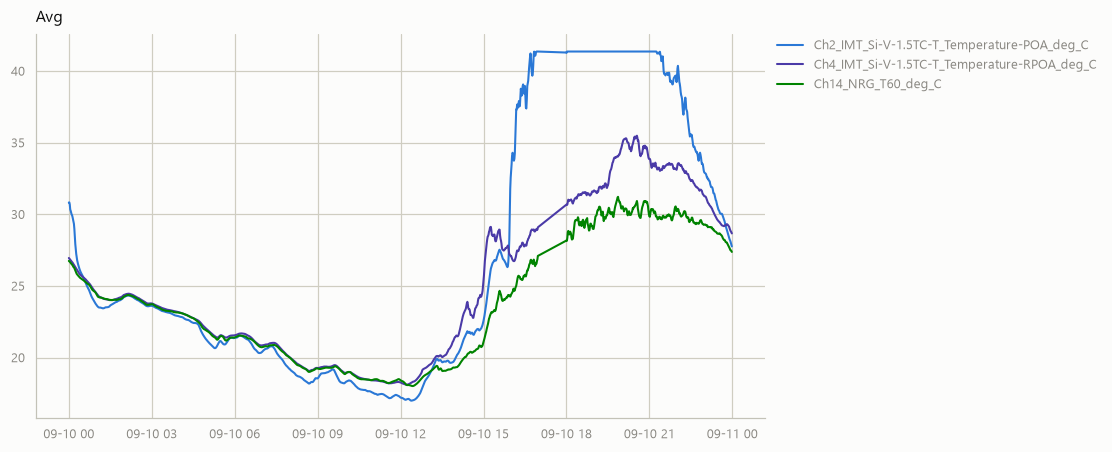

In [12]:
plot_together(
    df,
    [
        "Ch2_IMT_Si-V-1.5TC-T_Temperature-POA_deg_C",
        "Ch4_IMT_Si-V-1.5TC-T_Temperature-RPOA_deg_C",
        "Ch14_NRG_T60_deg_C",
    ],
    statistic="Avg",
)

The IMT POA temperature climbed with the day and then stopped dead at 41.3592 C for two and a half hours, while the T60 air temperature and the rear-facing IMT beside it carried on moving. That is the channel clamping at the top of its scale, not the module holding a temperature.

It comes back as two findings rather than one because the missing minute at 20:32 falls inside it, and `stall_runs` never joins a run across a gap -- the two runs are the same fault either side of a dropped sample.

The other stall is the anemometer, which held 0.35 m/s -- its offset, so a dead stop -- for nearly seventeen hours while the vane it shares a boom with swung through 270 degrees of direction. Wind that moves a vane moves cups. Metres per second and degrees have no business on one axes, so these two get `plot_signals` and an axes each.

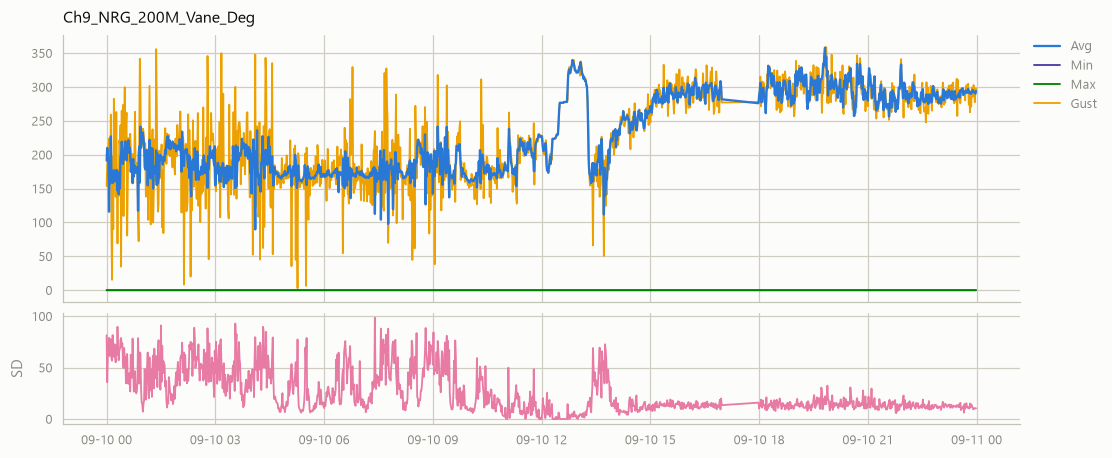

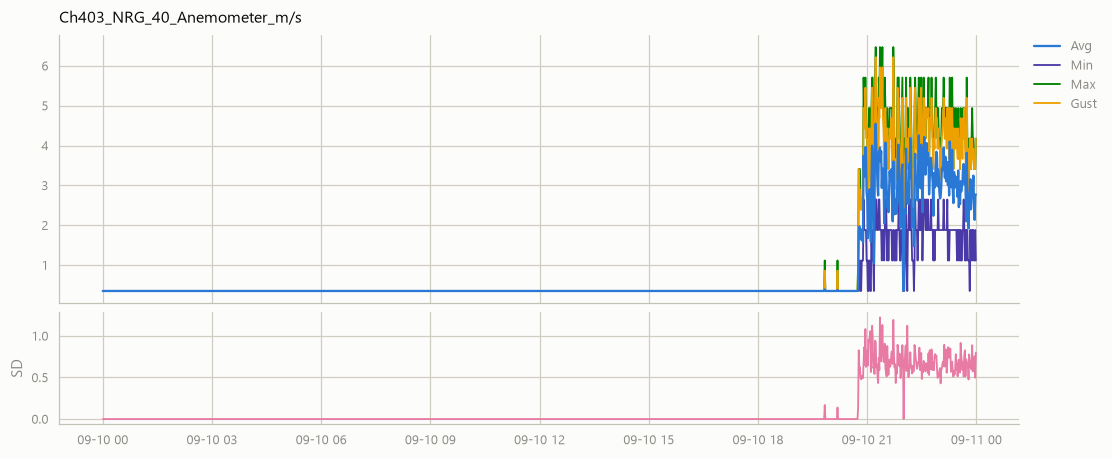

In [13]:
plot_signals(df, columns=[c for c in df.columns if c.startswith(("Ch403_", "Ch9_"))])

## The daylight pass

Some checks mean nothing at night. Irradiance legitimately sits at zero for ten hours, so a stall check over a whole day would report every radiometer on the site as stuck; the albedo is a ratio of two numbers that are both near zero after dark, and wanders past 1 every night at every site.

Those checks are held back for a second pass over the daylight rows alone. `spec_for(sunlit=True)` is that pass's spec and `daylight` is its rows -- the sun's position computed from the header coordinates, so a logger whose own angles are wrong doesn't get to choose which rows its irradiance is judged on. No check is in both passes, so the two sets of findings concatenate into one report without double-counting anything.

In [14]:
sunlit_spec = measurement.spec_for(df, reader.Site_info, sunlit=True)
sunlit = measurement.daylight(df, reader.Site_info)

sunlit_findings = validation.validate(sunlit, sunlit_spec)
validation.summarize(sunlit_findings, sunlit_spec)

,check,signal,n_findings,pass
0,range,Ch305_Avg_Albedo,0,True
1,range,Ch305_Max_Albedo,0,True
2,range,Ch305_Min_Albedo,0,True
3,range,Ch305_SD_Albedo,0,True
4,stall,Ch101_Avg_Hukseflux_SR30-GHI_Irradiance_W/m^2,0,True
5,stall,Ch108_Avg_Hukseflux_SR30-POA_Irradiance_W/m^2,0,True
6,stall,Ch1_Avg_IMT_Si-V-1.5TC-T_Irradiance-POA_W/m^2,0,True
7,stall,Ch304_Avg_DNI_W/m^2,0,True
8,stall,Ch305_Avg_Albedo,0,True
9,stall,Ch3_Avg_IMT_Si-V-1.5TC-T_Irradiance-RPOA_W/m^2,0,True


Nothing. Every radiometer on the tower kept moving through the day and the albedo stayed inside a fraction, which is the whole of what this pass has to say.

Both sets of findings side by side, since they are one report:

In [15]:
pd.concat([findings, sunlit_findings], ignore_index=True).groupby("check").size()

check
gap      2
range    6
solar    1
stall    3
dtype: int64

## Availability

The gap findings say where the record stops; availability says whether the days asked for arrived at all. The difference is the ends -- a run that started late or stopped early leaves no step in its own index to find, and is missing data all the same.

In [16]:
percent, missing = validation.availability("2026-09-10", "2026-09-10", df)

print(f"{percent:.2f}% of the expected samples arrived")
missing

95.76% of the expected samples arrived


,start,end,duration,n_missing
0,2026-09-10 16:59:00+00:00,2026-09-10 17:59:00+00:00,0 days 01:00:00,60
1,2026-09-10 20:32:00+00:00,2026-09-10 20:33:00+00:00,0 days 00:01:00,1


One statistical file never made it off the logger, which is the hour, plus a single dropped minute.

Plot every signal to visually inspect. Statistics of the same signal share an axes except SD, which is shown separately since it usually has a much smaller scale.

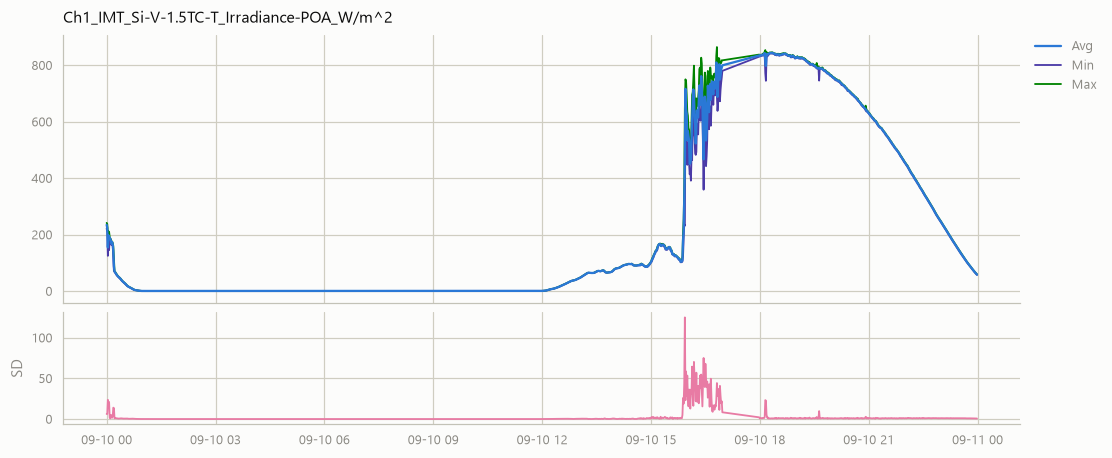

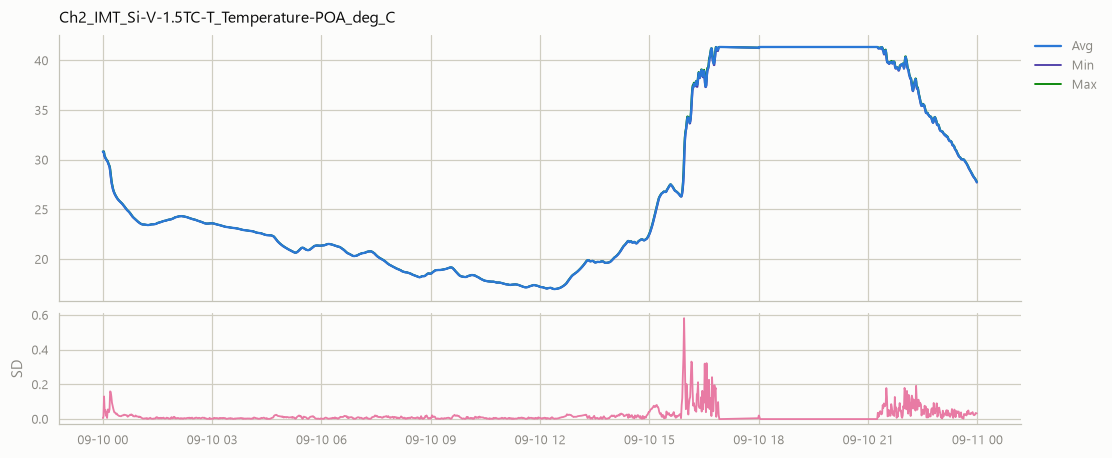

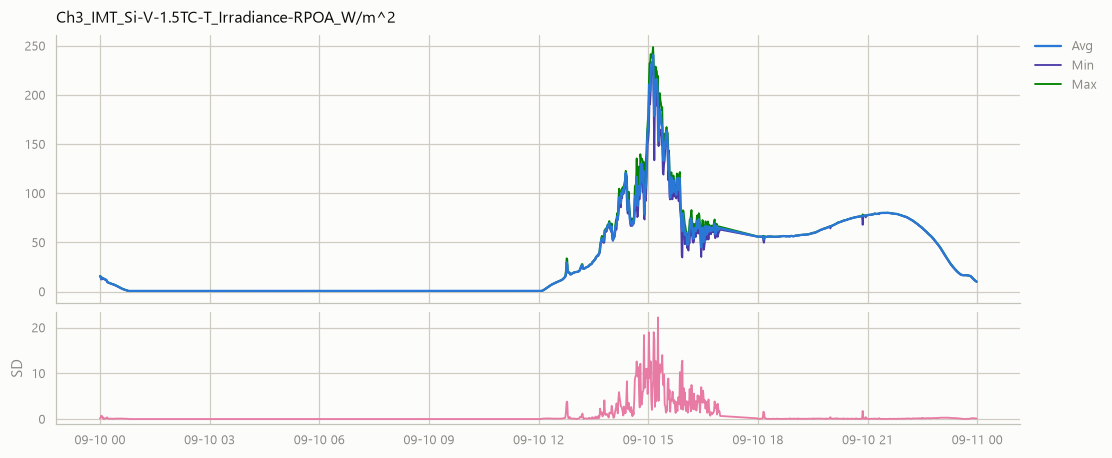

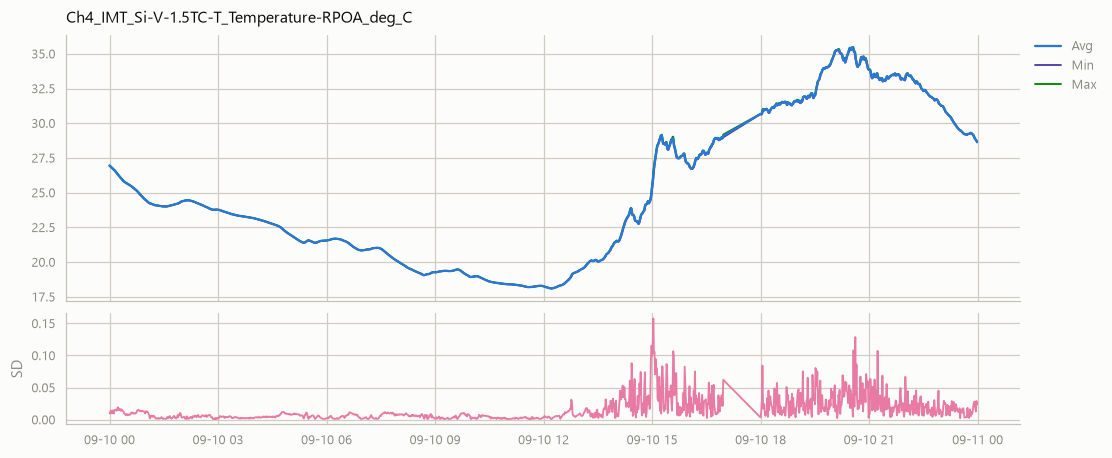

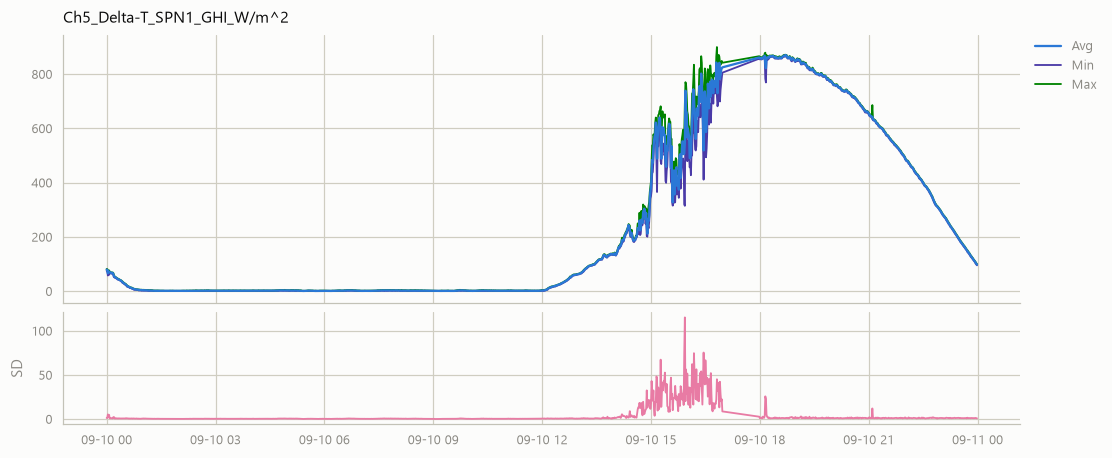

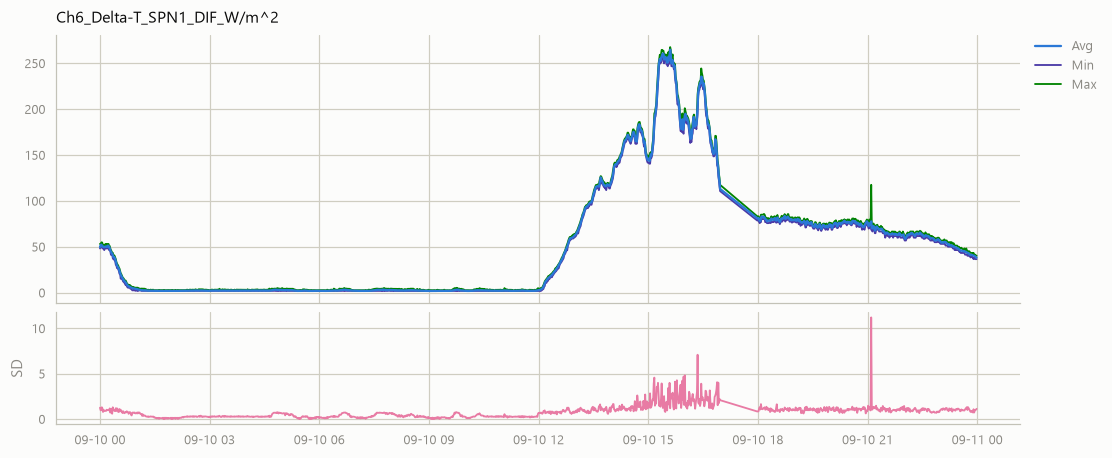

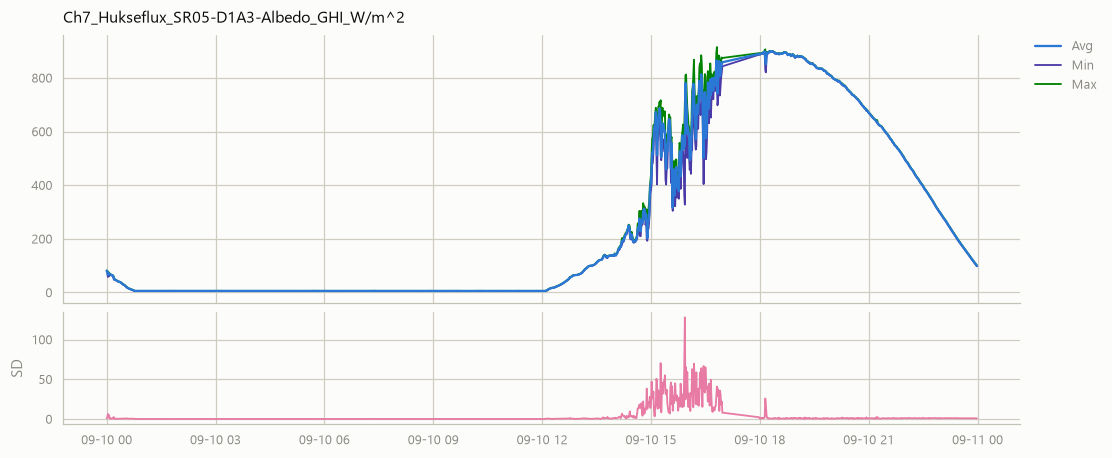

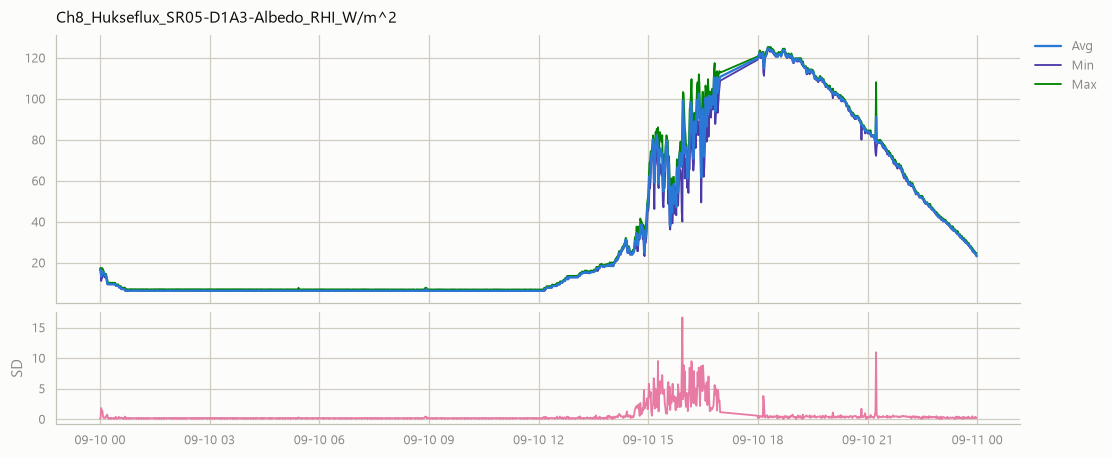

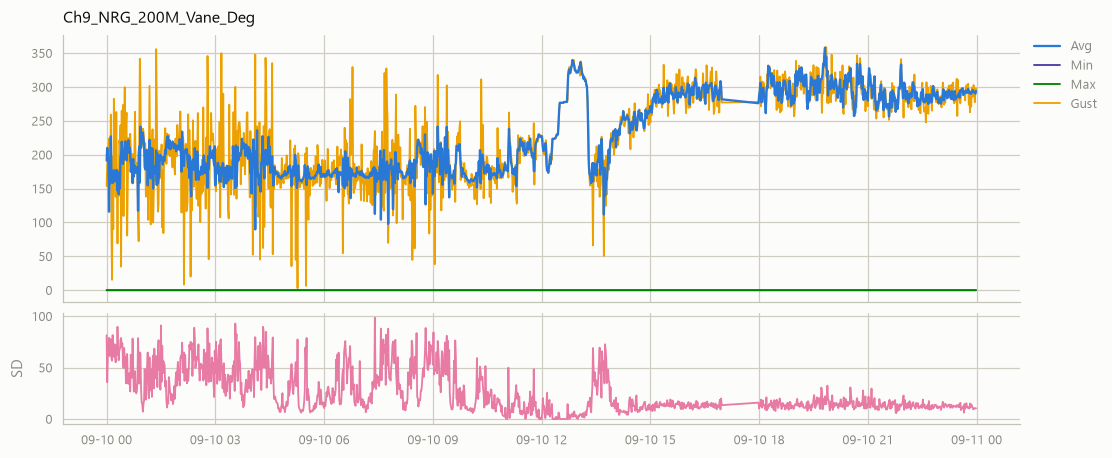

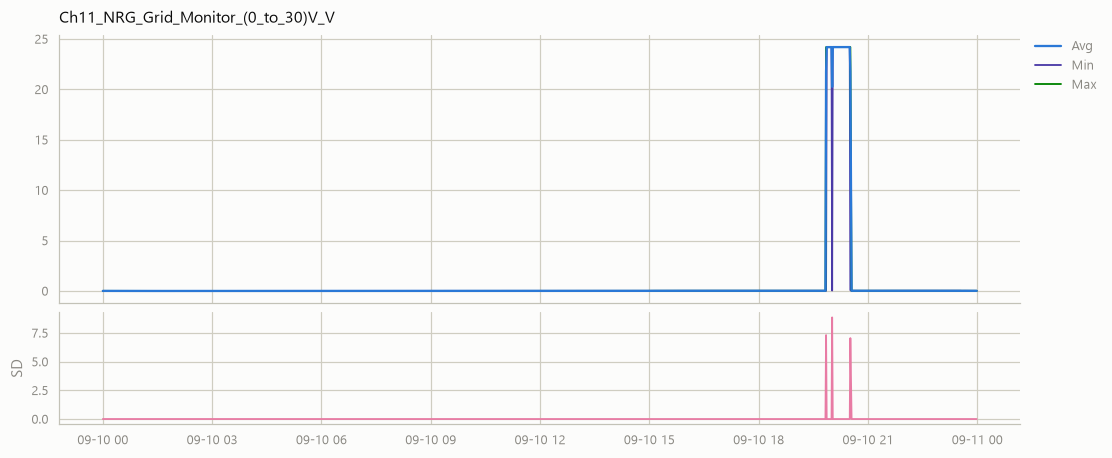

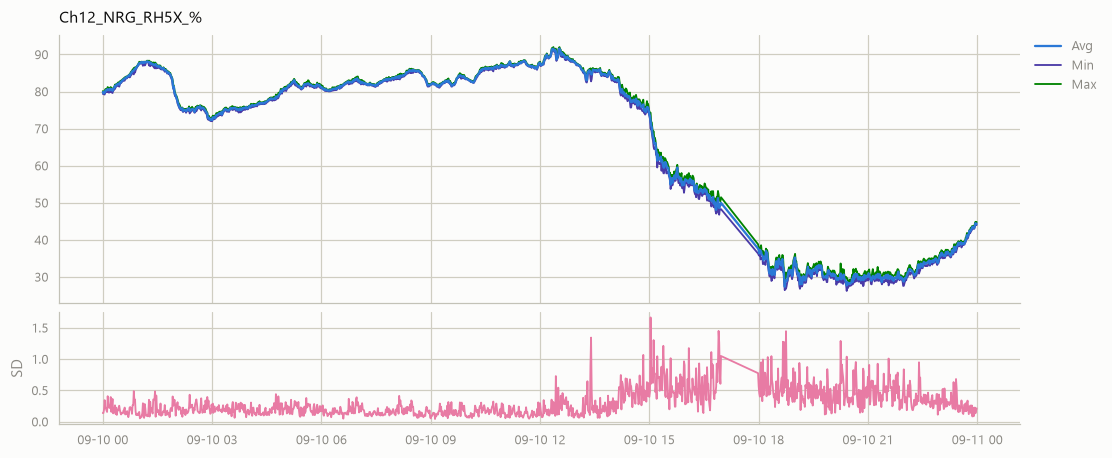

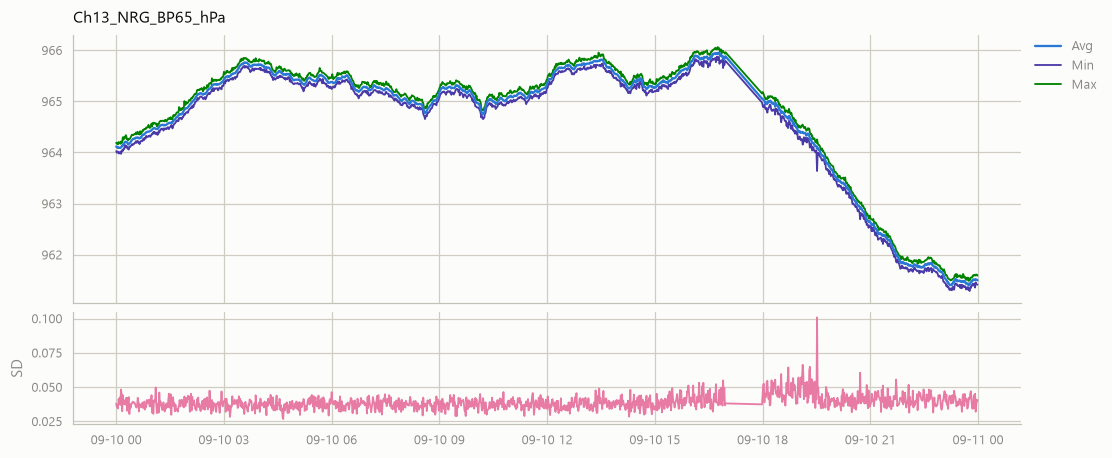

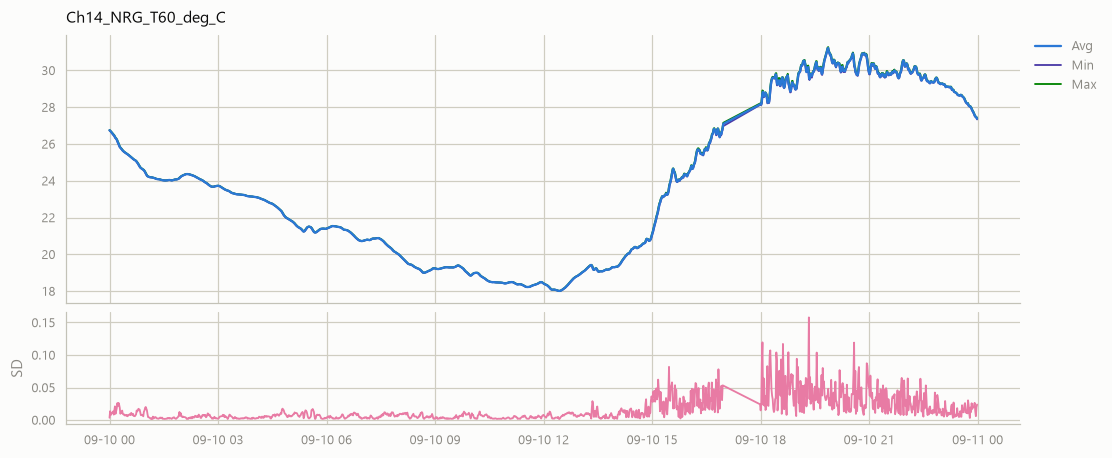

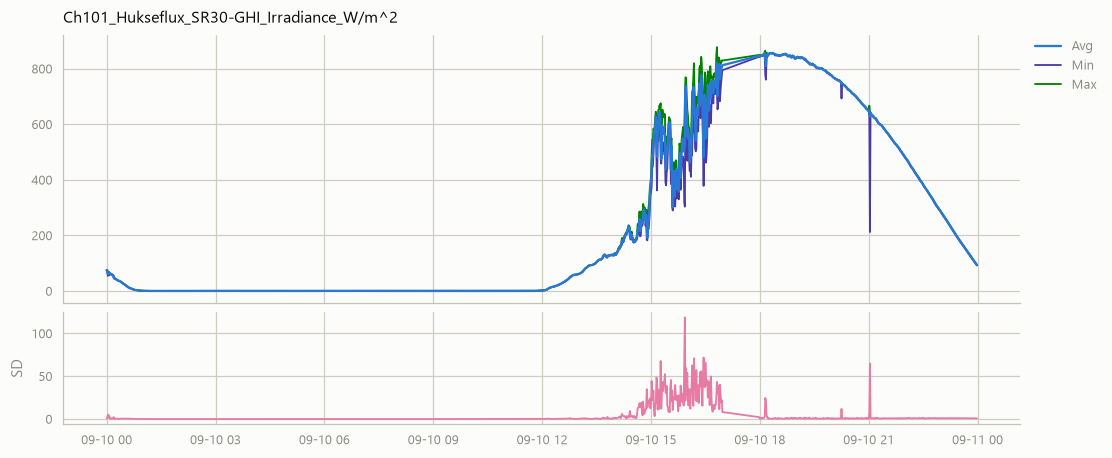

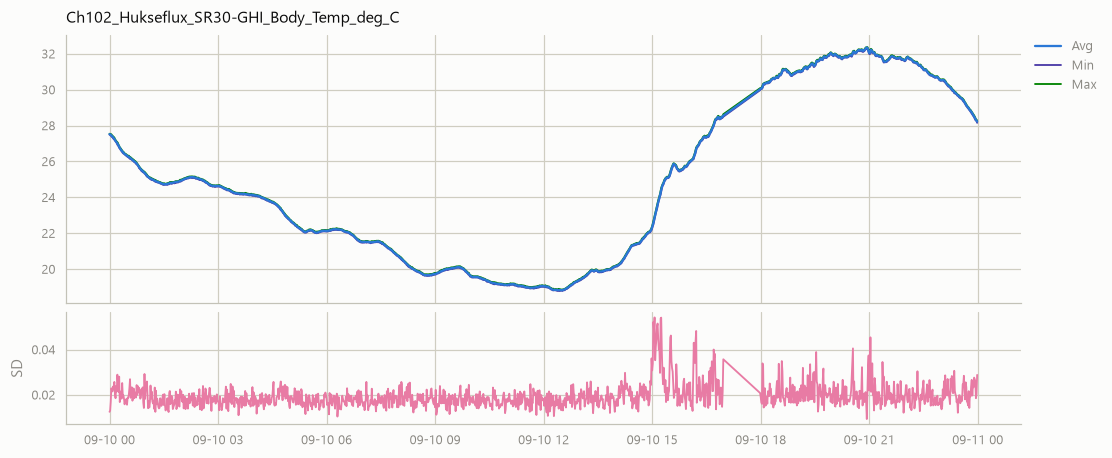

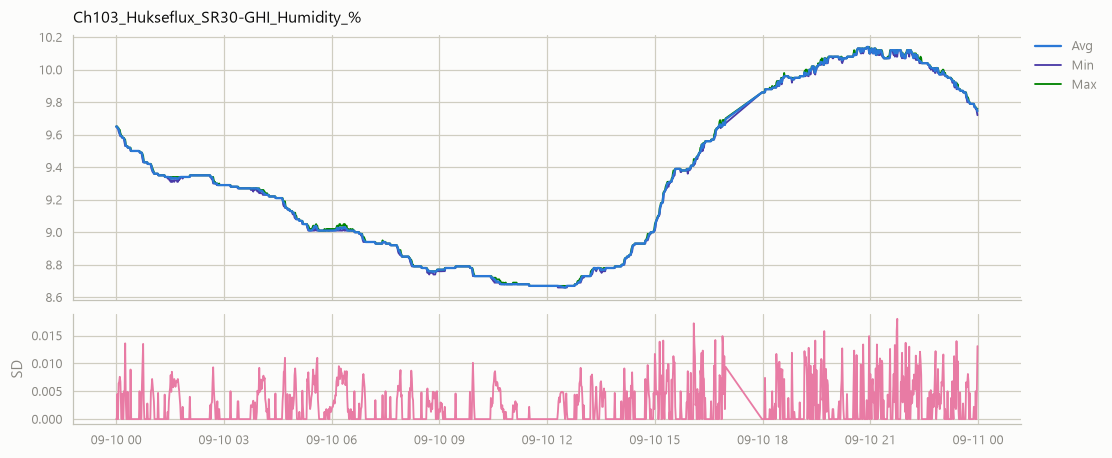

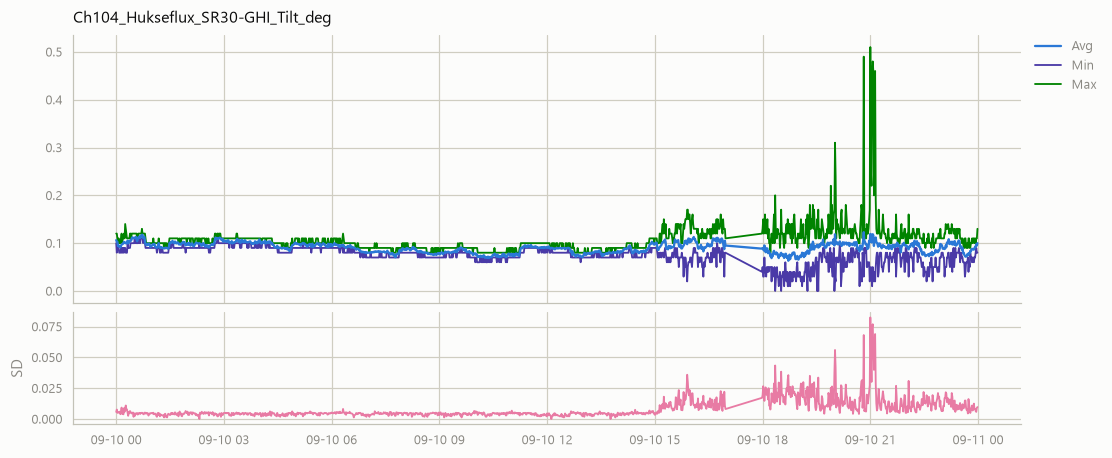

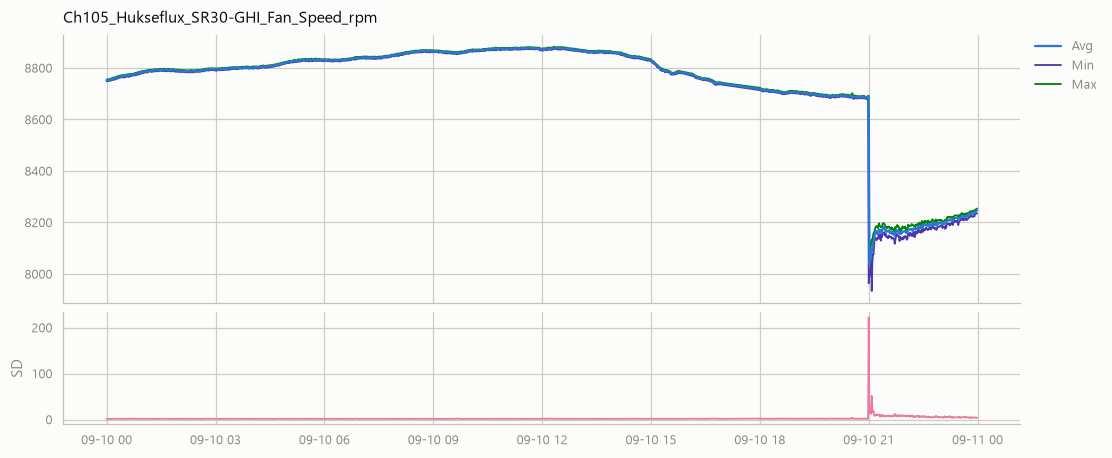

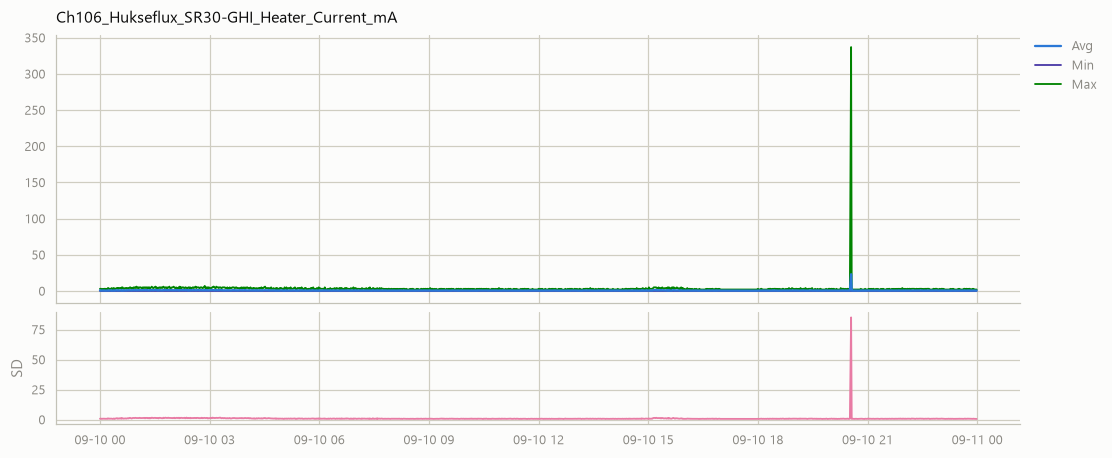

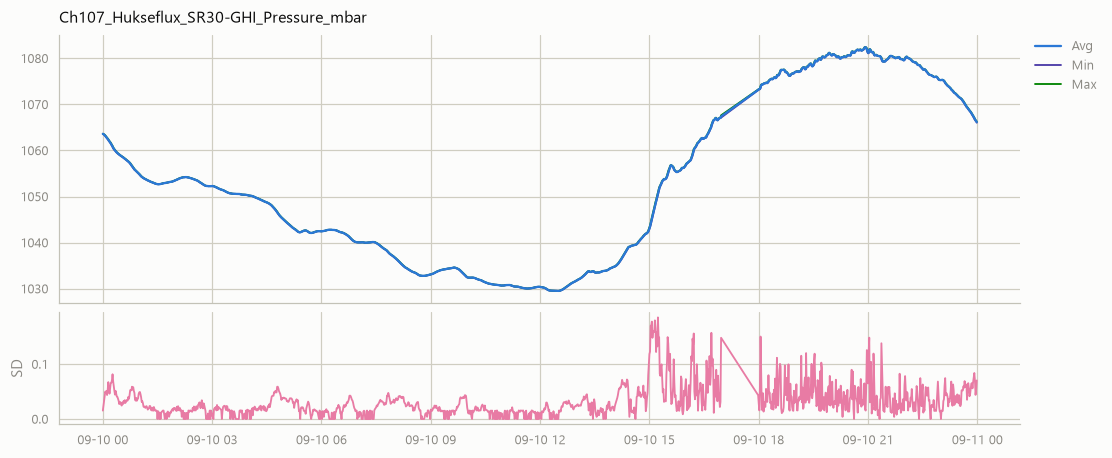

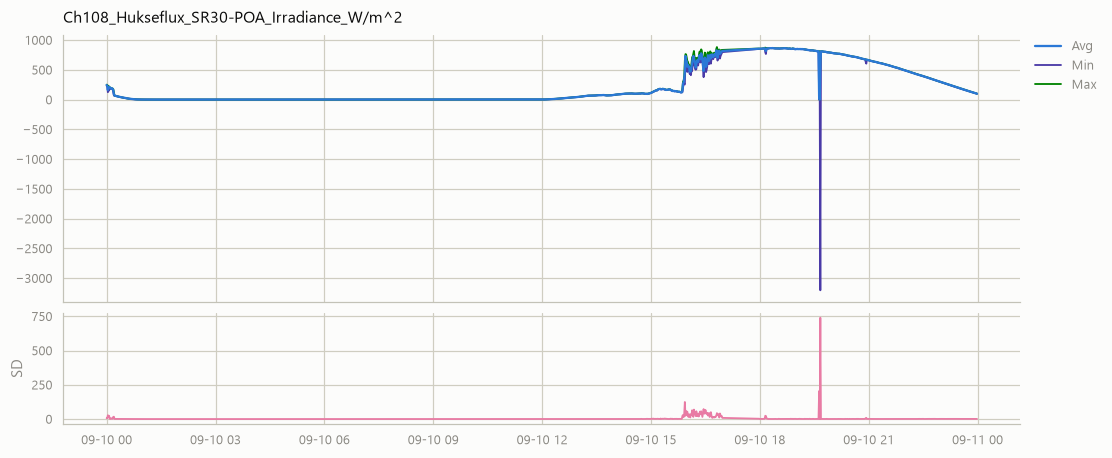

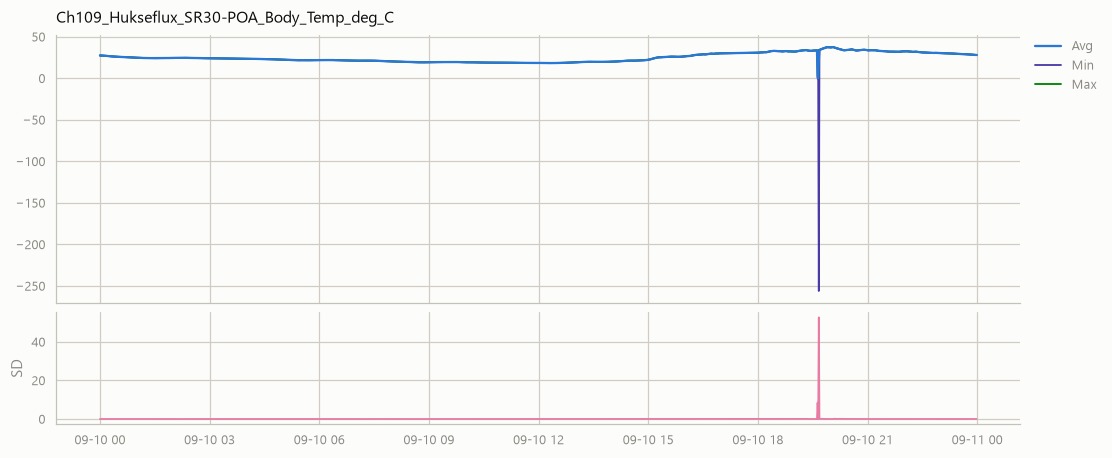

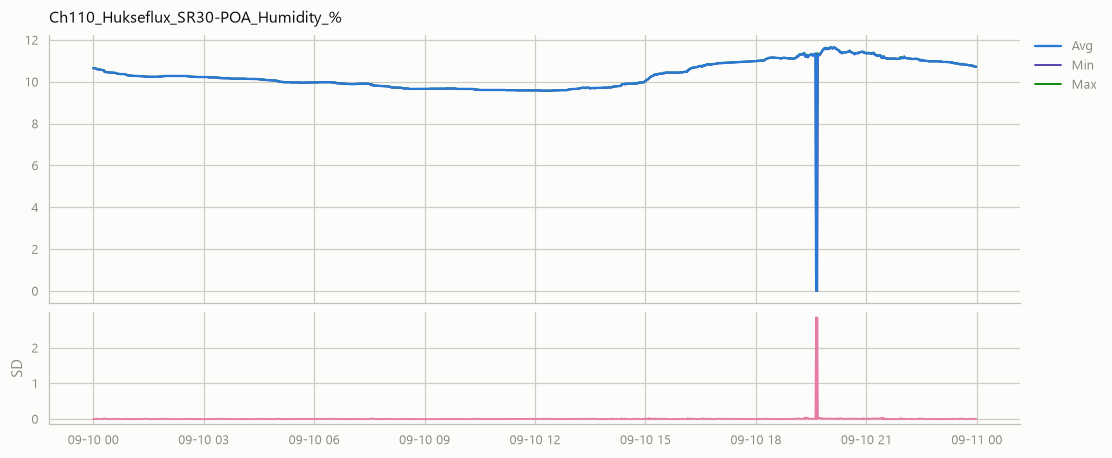

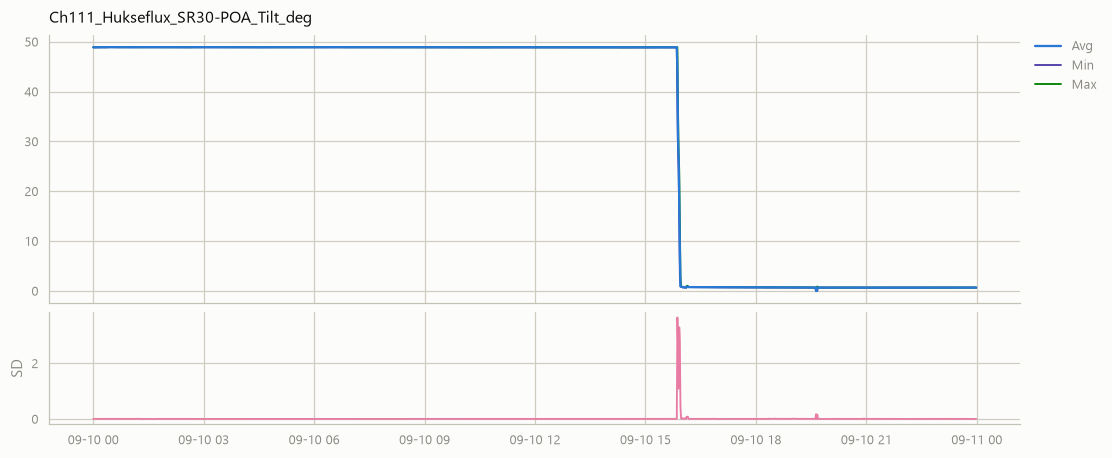

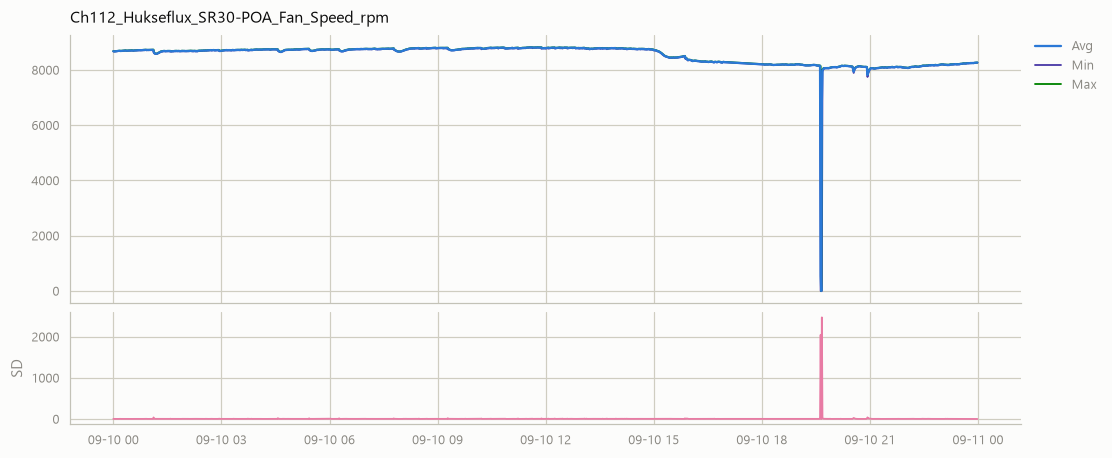

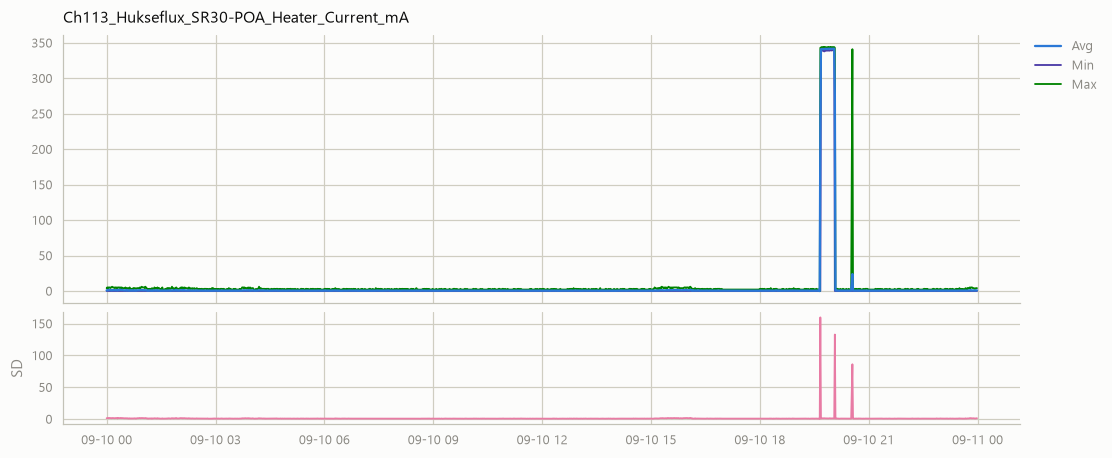

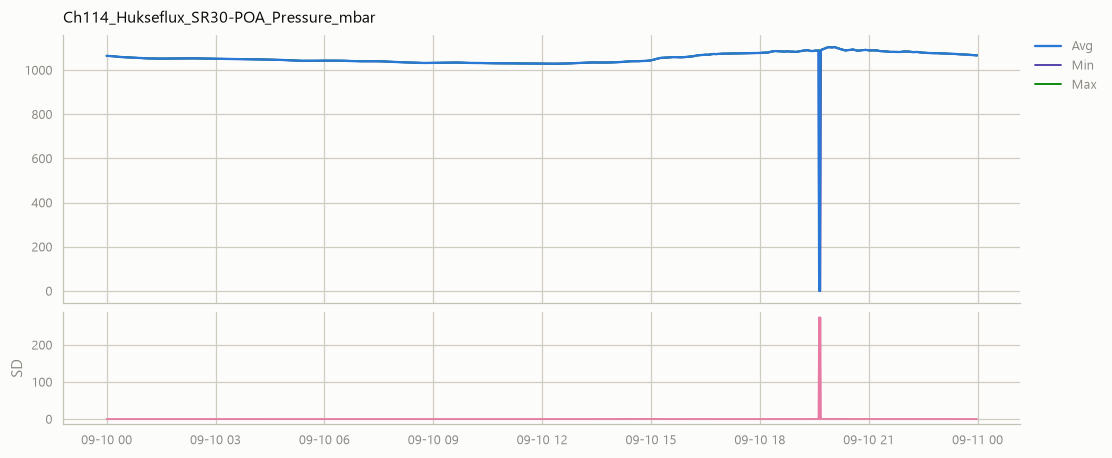

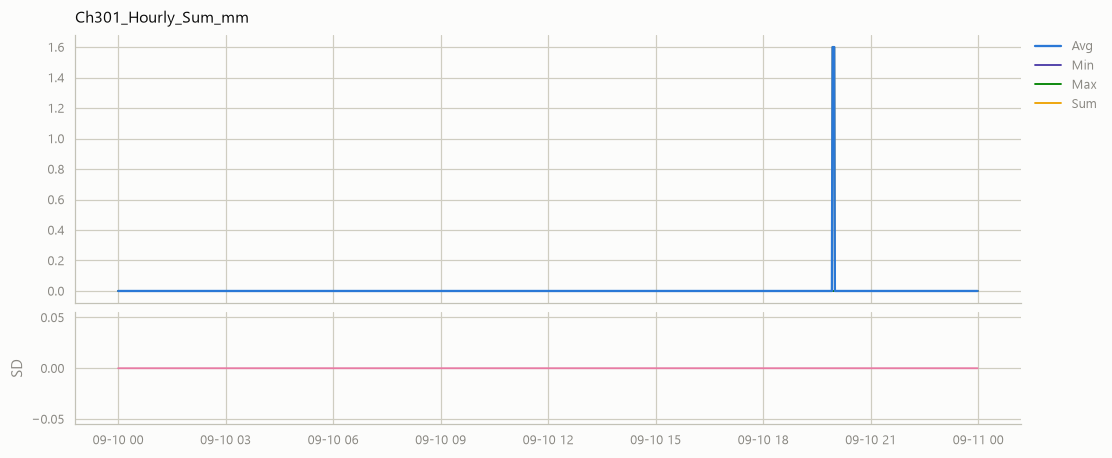

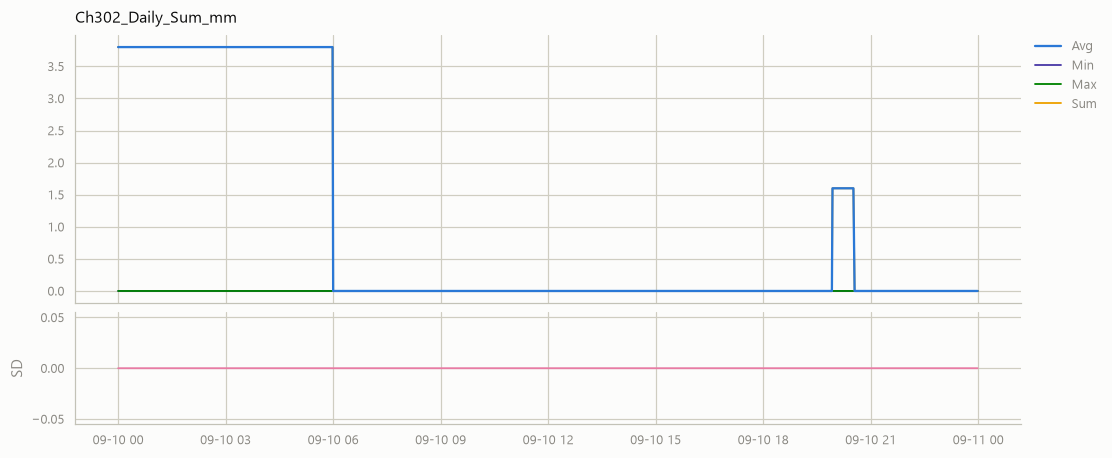

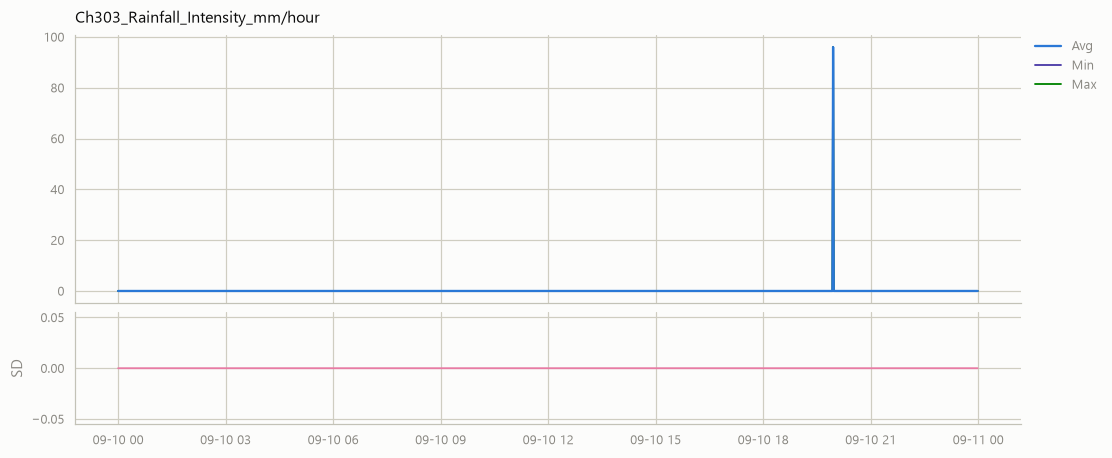

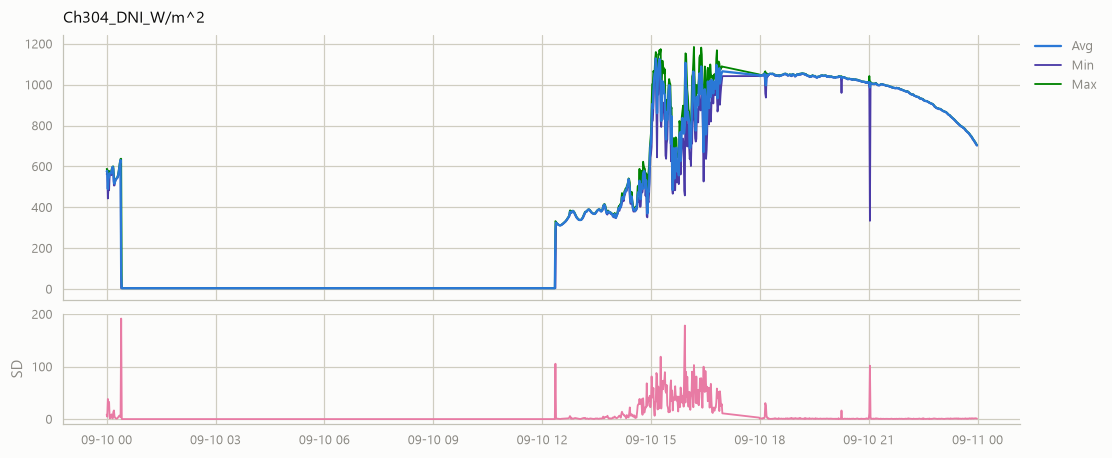

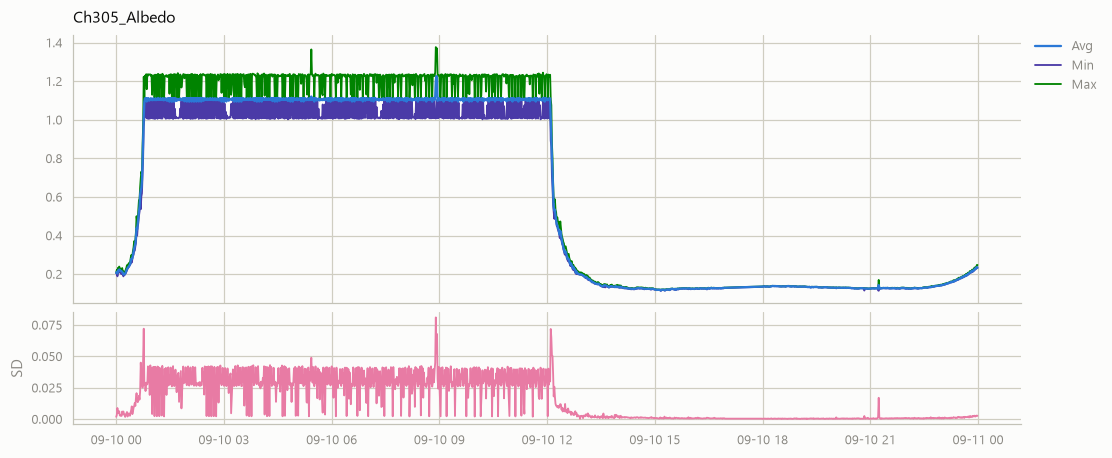

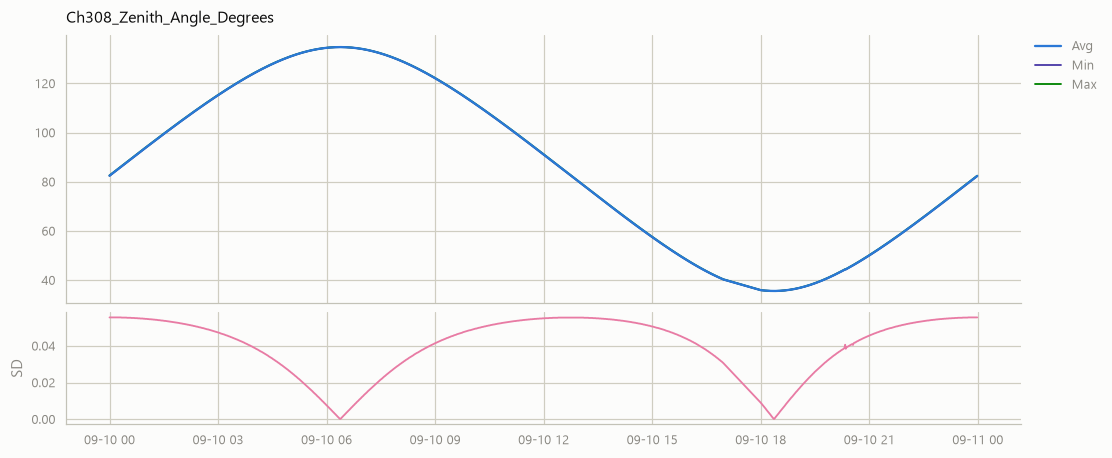

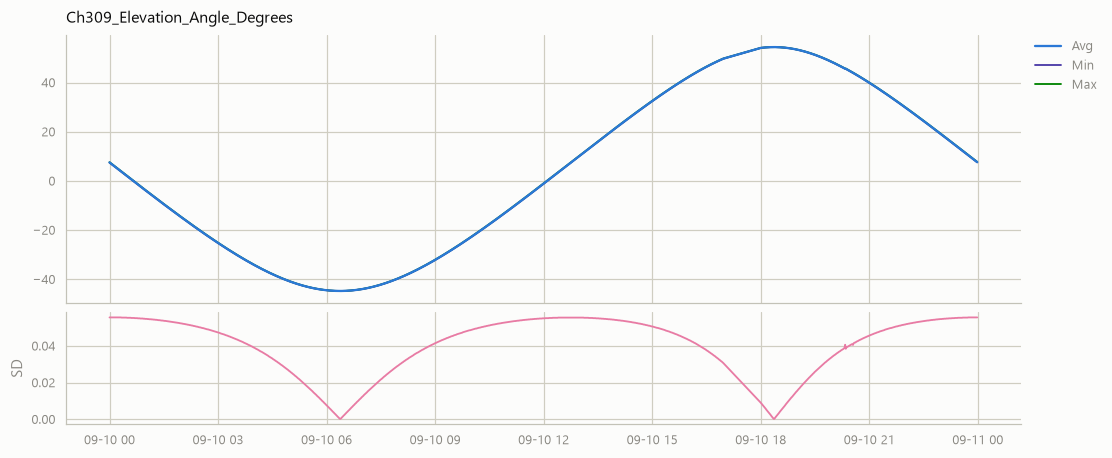

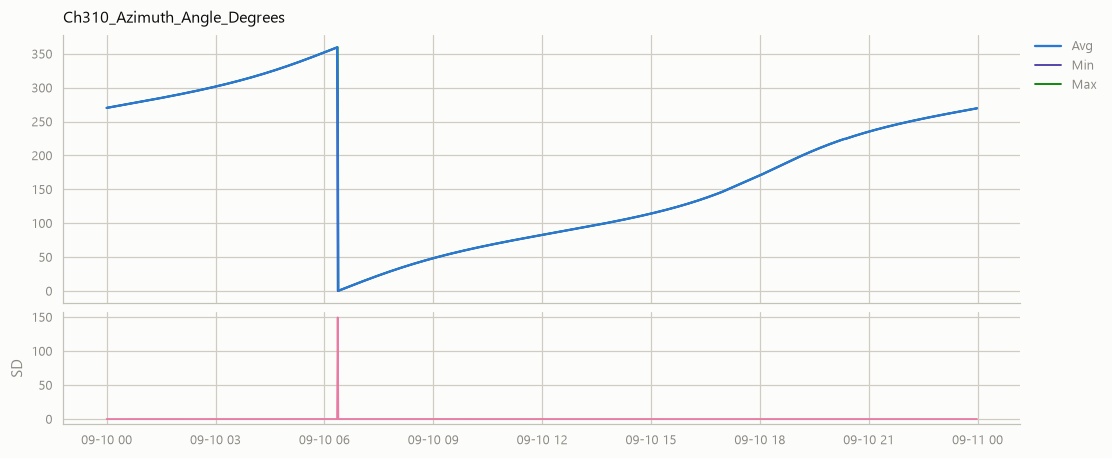

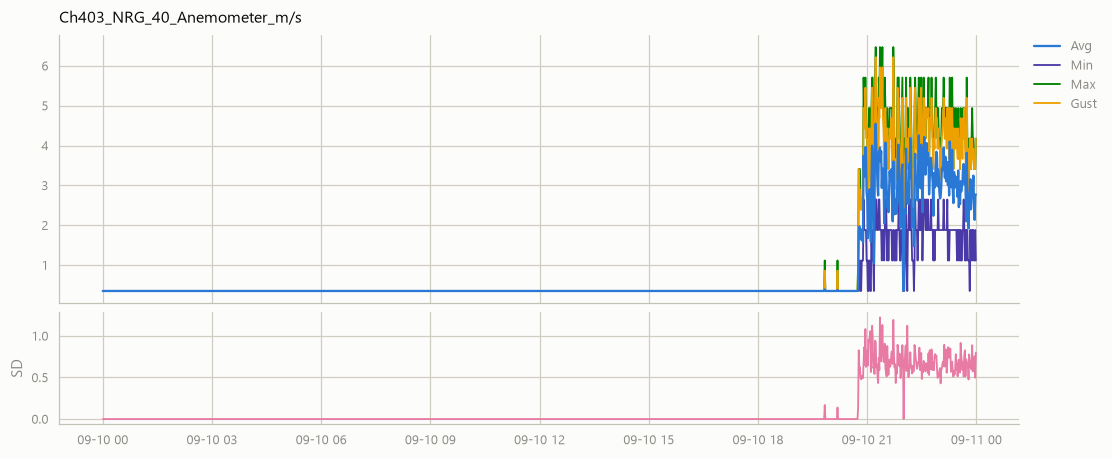

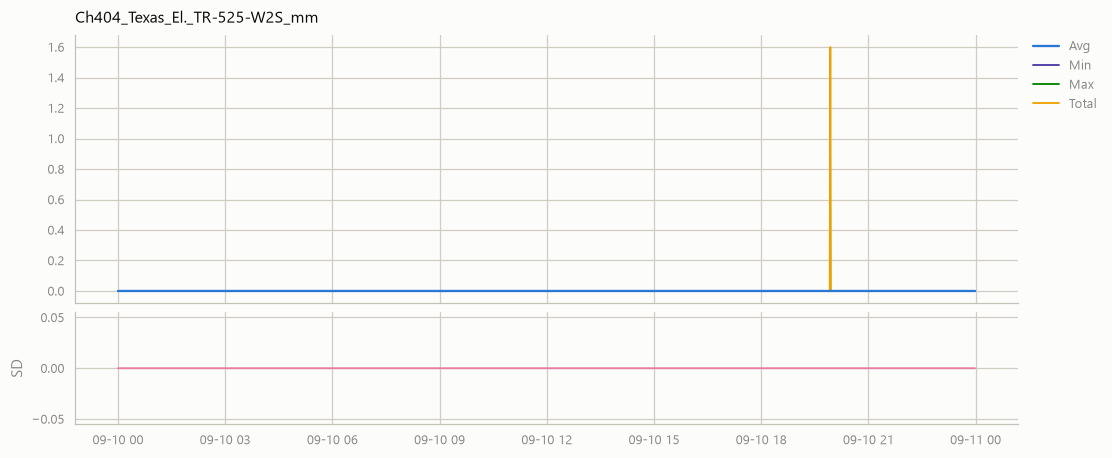

In [17]:
plot_signals(df)